# Import and Helper

In [1]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import PatchPoint, PatchSet, plot_patchset


# ============================================================
# Imports / reloading / helper functions
# ============================================================
import sys
from importlib import reload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import noninteracting
import interaction
import frg_kernel
import channels
import frg_flow

reload(noninteracting)
reload(interaction)
reload(frg_kernel)
reload(channels)
reload(frg_flow)

from interaction import BareExtendedHubbard
from channels import SZ0ChannelBuilder
from frg_flow import FRGFlowSolverSZ0, BareSZ0VertexFromInteraction, FlowStepRecord
import instability
reload(instability)

from instability import (
    InstabilityConfig,
    diagnose_kernel_collection,
)
from frg_kernel import FlowConfig

def build_sz0_builder_from_solver(solver, *, Landau_F=None):
    if Landau_F is None:
        Landau_F = getattr(solver, "diagnosis_landau_F", False)
    return SZ0ChannelBuilder(
        vertex=solver.current_vertex_accessor(),
        patchsets=solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
        q_merge_tol_red=getattr(solver, "q_merge_tol_red", 5e-2),
        q_key_decimals=getattr(solver, "q_key_decimals", 10),
        Landau_F=Landau_F,
    )


def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def sign_aware_channel_score(channel_name, M):
    H = hermitian_part(M)
    evals, _ = np.linalg.eigh(H)
    eval_pos_max = float(np.max(evals))
    eval_neg_min = float(np.min(evals))

    if channel_name.startswith("pp"):
        physical_score = max(eval_pos_max, 0.0)
        chosen_eval = eval_pos_max
        chosen_sign = "positive"
    elif channel_name.startswith("ph"):
        physical_score = max(-eval_neg_min, 0.0)
        chosen_eval = eval_neg_min
        chosen_sign = "negative"
    else:
        raise ValueError(f"Unknown channel name: {channel_name}")

    return {
        "eval_pos_max": eval_pos_max,
        "eval_neg_min": eval_neg_min,
        "physical_score": float(physical_score),
        "chosen_eval": float(chosen_eval),
        "chosen_sign": chosen_sign,
        "herm_resid": float(np.max(np.abs(M - M.conjugate().T))),
    }


def evaluate_selected_Qs(builder, diagnosis_Qs, *, landau_F=False):
    rows = []
    kernel_store = {}
    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=landau_F)
        kernel_store[iq] = {"Q": np.asarray(Q, dtype=float), "kernels": kernel_dict}
        for ch_name, ker in kernel_dict.items():
            info = sign_aware_channel_score(ch_name, ker.matrix)
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": np.asarray(Q, dtype=float),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                **info,
            })
    df = pd.DataFrame(rows)
    return df, kernel_store


def fmt_q(q, nd=3):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def plot_signaware_bars(df, *, title):
    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]
    channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(channels_order):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0]["physical_score"]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("sign-aware physical score")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def choose_signaware_eigenpair(channel_name, M):
    H = hermitian_part(M)
    evals, evecs = np.linalg.eigh(H)
    if channel_name.startswith("pp"):
        idx = int(np.argmax(evals))
    elif channel_name.startswith("ph"):
        idx = int(np.argmin(evals))
    else:
        raise ValueError(f"Unknown channel_name={channel_name}")
    vec = np.asarray(evecs[:, idx], dtype=complex)
    val = float(evals[idx].real)
    vec = vec / np.linalg.norm(vec)
    return val, vec


def leading_row_from_df(df):
    if len(df) == 0:
        raise ValueError("Empty diagnosis dataframe.")
    return df.sort_values("physical_score", ascending=False).iloc[0]


def print_step_summary(rec):
    payload = rec.diagnosis_payload
    if "sign_aware" not in payload:
        print(
            f"step={rec.step_index:4d} | T={rec.temperature:.6f} | "
            f"rhs_norm={rec.rhs_norm:.3e} | no sign-aware payload"
        )
        return

    sa = payload["sign_aware"]
    lead_ch = sa["leading_channel"]
    lead_qi = sa["leading_Q_index"]
    lead_q = np.asarray(sa["leading_Q"], dtype=float)
    lead_score = sa["leading_score"]

    # per-channel scores at the leading Q
    q_entry = None
    for item in sa["per_Q"]:
        if int(item["Q_index"]) == int(lead_qi):
            q_entry = item
            break

    if q_entry is None:
        print(
            f"step={rec.step_index:4d} | T={rec.temperature:.6f} | "
            f"rhs_norm={rec.rhs_norm:.3e} | leader={lead_ch} @ {fmt_q(lead_q)} score={lead_score:.3e}"
        )
        return

    channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]
    score_str = ", ".join(
        f"{ch}={float(q_entry['channels'][ch]['physical_score']):.3e}" for ch in channels_order
    )
    print(
        f"step={rec.step_index:4d} | T={rec.temperature:.6f} | rhs_norm={rec.rhs_norm:.3e} | "
        f"leader={lead_ch} @ Q{lead_qi}:{fmt_q(lead_q)} score={lead_score:.3e} | {score_str}"
    )


def manual_run_flow_live(solver, snapshot_steps=None):
    if snapshot_steps is None:
        snapshot_steps = set()
    else:
        snapshot_steps = set(int(x) for x in snapshot_steps)

    temps = solver.temperature_path
    snapshots = {}

    rec0 = FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    if 0 in snapshot_steps:
        snapshots[0] = make_snapshot_from_solver(solver, label=f"step_0")

    print_step_summary(rec0)
    if rec0.instability:
        return solver.history, snapshots

    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])
        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        if rec.step_index in snapshot_steps:
            snapshots[rec.step_index] = make_snapshot_from_solver(
                solver, label=f"step_{rec.step_index}"
            )

        print_step_summary(rec)

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            print("instability_reason:", rec.instability_reason)
            print("termination_reason:", rec.termination_reason)
            break

    return solver.history, snapshots


def history_to_dataframe(history):
    rows = []
    for rec in history:
        row = {
            "step_index": rec.step_index,
            "T": rec.temperature,
            "dT": rec.dT,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "accepted_substeps": rec.accepted_substeps,
            "max_rel_update": rec.max_rel_update,
            "instability": rec.instability,
            "instability_reason": rec.instability_reason,
            "termination_reason": rec.termination_reason,
        }
        if "sign_aware" in rec.diagnosis_payload:
            sa = rec.diagnosis_payload["sign_aware"]
            row["leading_channel"] = sa["leading_channel"]
            row["leading_Q_index"] = sa["leading_Q_index"]
            row["leading_Qx"] = float(np.asarray(sa["leading_Q"], dtype=float)[0])
            row["leading_Qy"] = float(np.asarray(sa["leading_Q"], dtype=float)[1])
            row["leading_score"] = float(sa["leading_score"])
        rows.append(row)
    return pd.DataFrame(rows)

from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray

def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )

def make_snapshot_accessor(snapshot):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])
    return accessor

def make_builder_from_snapshot(snapshot, solver):
    return SZ0ChannelBuilder(
        make_snapshot_accessor(snapshot),
        solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
    )

def kernel_bundle_at_Q(snapshot, solver, Q):
    """
    Return the 8 objects you want to visualize:
      pp: V, V_exchange, V_singlet, V_triplet
      ph: Vd, Vx, Vcharge, Vspin
    """
    builder = make_builder_from_snapshot(snapshot, solver)
    Q = np.array(Q, dtype=float)

    # pp
    V_pp_raw, _, _ = builder._pp_raw_v(Q)
    V_pp_ex = builder._pp_out_exchange_v(Q)
    K_pp_s = builder.pp_singlet(Q).matrix
    K_pp_t = builder.pp_triplet(Q).matrix

    # ph
    Vd = builder.ph_direct(Q).matrix
    Vx = builder.ph_exchange(Q).matrix
    K_ph_c = builder.ph_charge(Q).matrix
    K_ph_s = builder.ph_spin(Q).matrix

    return {
        "pp_V": V_pp_raw,
        "pp_V_exchange": V_pp_ex,
        "pp_singlet": K_pp_s,
        "pp_triplet": K_pp_t,
        "ph_Vd": Vd,
        "ph_Vx": Vx,
        "ph_charge": K_ph_c,
        "ph_spin": K_ph_s,
    }

def leading_eval(M):
    vals = np.linalg.eigvals(M)
    i = np.argmax(np.abs(vals))
    return vals[i]

def summarize_bundle(bundle):
    rows = []
    for name, M in bundle.items():
        lam = leading_eval(M)
        rows.append({
            "kernel": name,
            "max_abs_entry": float(np.max(np.abs(M))),
            "lead_eval_abs": float(np.abs(lam)),
            "lead_eval_real": float(np.real(lam)),
            "lead_eval_imag": float(np.imag(lam)),
        })
    import pandas as pd
    return pd.DataFrame(rows).sort_values("lead_eval_abs", ascending=False)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

# ------------------------------------------------------------
# reciprocal helpers
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can

# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]

def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]

def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # t = 0, 1/p, ..., (p-1)/p ; exclude t=1 to avoid explicit duplication
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)

def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)

# ------------------------------------------------------------
# duplicated-M removal (patch reps only)
# ------------------------------------------------------------
def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    """
    Return indices to KEEP among the standard exact-M loop points.

    Only the 6 anchor points are checked for modulo-G duplication:
        0, p, 2p, 3p, 4p, 5p
    where p = points_per_edge.

    All non-anchor points are always kept.
    """
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k = M6[local_anchor_idx]
        k_can = _canonicalize_k_mod_G(model, k)

        duplicated = False
        for q_can in seen_classes:
            if np.linalg.norm(k_can - q_can) < tol:
                duplicated = True
                break

        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)

    return np.flatnonzero(keep)

# ------------------------------------------------------------
# gauge fixing
# ------------------------------------------------------------
def _normalize_eigvec(u):
    u = np.asarray(u, dtype=complex)
    nrm = np.linalg.norm(u)
    if nrm == 0:
        raise ValueError("Encountered zero-norm eigenvector.")
    return u / nrm

def _anchor_phase(u, method="max_component"):
    u = _normalize_eigvec(u)
    if method == "max_component":
        idx = int(np.argmax(np.abs(u)))
        if np.abs(u[idx]) > 0:
            u = u * np.exp(-1j * np.angle(u[idx]))
    elif method == "first_component":
        if np.abs(u[0]) > 0:
            u = u * np.exp(-1j * np.angle(u[0]))
    else:
        raise ValueError("method must be 'max_component' or 'first_component'")
    return u

def smooth_patch_eigvecs(eigvecs, *, close_loop=True, anchor_method="max_component"):
    """
    Parallel-transport gauge fixing along the kept patch loop.

    1. Anchor first vector phase.
    2. For each next patch, rotate so <u_i | u_{i+1}> is real positive.
    3. Optionally distribute the final loop mismatch around the loop.

    Returns
    -------
    U_fixed : ndarray, shape (Npatch, Norb)
    loop_phase : float
        phase mismatch of the final overlap before loop closure correction.
    """
    U = np.asarray(eigvecs, dtype=complex).copy()
    if U.ndim != 2:
        raise ValueError("eigvecs must have shape (Npatch, Norb).")

    N = U.shape[0]
    if N == 0:
        return U, 0.0

    U[0] = _anchor_phase(U[0], method=anchor_method)

    for p in range(1, N):
        U[p] = _normalize_eigvec(U[p])
        ov = np.vdot(U[p - 1], U[p])
        if np.abs(ov) > 1e-14:
            U[p] *= np.exp(-1j * np.angle(ov))
        else:
            U[p] = _anchor_phase(U[p], method=anchor_method)

    loop_phase = 0.0
    if N > 1:
        ov_last = np.vdot(U[-1], U[0])
        if np.abs(ov_last) > 1e-14:
            loop_phase = float(np.angle(ov_last))

    if close_loop and N > 1 and np.abs(loop_phase) > 1e-14:
        # distribute mismatch smoothly along the loop
        for p in range(N):
            U[p] *= np.exp(1j * (p / N) * loop_phase)

        # re-anchor first patch and re-parallel-transport to keep neighboring overlaps smooth
        U[0] = _anchor_phase(U[0], method=anchor_method)
        for p in range(1, N):
            ov = np.vdot(U[p - 1], U[p])
            if np.abs(ov) > 1e-14:
                U[p] *= np.exp(-1j * np.angle(ov))

    for p in range(N):
        U[p] = _normalize_eigvec(U[p])

    return U, loop_phase

# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
def _patch_keep_indices_exclude_strict_M_anchors(points_per_edge):
    """
    Return indices to KEEP after removing all 6 strict M-anchor points
    from the standard exact-M hex loop.

    Standard indexing convention:
        full loop has n_full = 6 * points_per_edge points
        the strict M anchors are exactly:
            0, p, 2p, 3p, 4p, 5p
        where p = points_per_edge

    Requirements
    ------------
    points_per_edge >= 2
    """
    p = int(points_per_edge)
    if p < 2:
        raise ValueError(
            "keep_strict_M_anchors=False requires points_per_edge >= 2, "
            "because for points_per_edge=1 all loop points are strict M anchors."
        )

    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    strict_M_ids = [i * p for i in range(6)]
    keep[strict_M_ids] = False

    return np.flatnonzero(keep)

def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    *,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
    keep_strict_M_anchors=True,
    gauge_fix=True,
    close_loop_gauge=True,
    gauge_anchor="max_component",
):
    """
    Build a manual exact-M hex-loop patchset.

    Parameters
    ----------
    points_per_edge : int
        Number of points sampled on each of the 6 edges of the M-hex loop.
        Total full-loop points = 6 * points_per_edge.

    remove_duplicate_M_modG : bool
        Only relevant when keep_strict_M_anchors=True.
        If True, keep strict M anchors but remove those duplicated modulo G.

    keep_strict_M_anchors : bool
        If False, remove all 6 strict M anchor points from patch representatives.
        This is often the cleaner choice when one wants to restore C3 more faithfully.

    gauge_fix : bool
        Whether to parallel-transport smooth the eigvecs on the kept loop.

    close_loop_gauge : bool
        Whether to distribute the residual loop phase.

    gauge_anchor : str
        Gauge anchor choice for the smoothing helper.
    """
    # ------------------------------------------------------------
    # 1) full standard loop
    # ------------------------------------------------------------
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    # ------------------------------------------------------------
    # 2) choose kept representatives
    # ------------------------------------------------------------
    if not keep_strict_M_anchors:
        keep_idx = _patch_keep_indices_exclude_strict_M_anchors(points_per_edge)
    elif remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
    else:
        keep_idx = np.arange(len(K_full))

    K_patch = K_full[keep_idx]

    # ------------------------------------------------------------
    # 3) plotting BZ
    # ------------------------------------------------------------
    bz_vertices = _hex_bz_vertices_for_plot(model)

    # ------------------------------------------------------------
    # 4) raw eigvecs / energies / velocities on kept reps
    # ------------------------------------------------------------
    raw_eigvecs = []
    energies = []
    velocities = []

    for k in K_patch:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)

    raw_eigvecs = np.asarray(raw_eigvecs, dtype=complex)

    # ------------------------------------------------------------
    # 5) explicit gauge fixing on kept patch loop
    # ------------------------------------------------------------
    if gauge_fix:
        fixed_eigvecs, loop_phase = smooth_patch_eigvecs(
            raw_eigvecs,
            close_loop=close_loop_gauge,
            anchor_method=gauge_anchor,
        )
        gauge_method = "manual_exact_M_hex_parallel_transport"
    else:
        fixed_eigvecs = np.asarray(
            [_normalize_eigvec(u) for u in raw_eigvecs],
            dtype=complex
        )
        loop_phase = 0.0
        gauge_method = "manual_exact_M_hex_raw"

    # ------------------------------------------------------------
    # 6) build PatchPoint list
    # ------------------------------------------------------------
    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K_patch, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=float(e),
                vF=np.asarray(vF, dtype=float),
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=np.asarray(u, dtype=complex),
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)

    suffix_dup = "_dropDupM" if (keep_strict_M_anchors and remove_duplicate_M_modG) else ""
    suffix_noM = "_noStrictM" if (not keep_strict_M_anchors) else ""
    suffix_g = "_gaugeFixed" if gauge_fix else "_rawGauge"

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # keep full loop for plotting
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_noM}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )
    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # keep original full contour
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )

def _ray_polygon_first_intersection(theta, vertices, *, tol=1e-12):
    """
    Intersect the ray r * e(theta), r>=0 with a closed polygon boundary.
    Return the closest valid intersection point.

    Parameters
    ----------
    theta : float
        Polar angle of the ray.
    vertices : array-like, shape (Nv, 2)
        Polygon vertices in loop order.

    Returns
    -------
    P : np.ndarray shape (2,)
        Closest intersection point on the polygon boundary.
    edge_index : int
        Which edge (vertices[i] -> vertices[i+1]) was hit.
    rmin : float
        Radius of the intersection.
    """
    vertices = np.asarray(vertices, dtype=float)
    e = np.array([np.cos(theta), np.sin(theta)], dtype=float)

    hits = []
    nv = len(vertices)

    for i in range(nv):
        A = vertices[i]
        B = vertices[(i + 1) % nv]
        d = B - A

        # Solve: r e = A + t d
        # => [e, -d] [r, t]^T = A
        M = np.column_stack([e, -d])
        det = np.linalg.det(M)
        if abs(det) < tol:
            continue

        r, t = np.linalg.solve(M, A)

        if r >= -tol and (-tol <= t <= 1 + tol):
            r = max(r, 0.0)
            t = min(max(t, 0.0), 1.0)
            P = A + t * d
            hits.append((r, i, P))

    if not hits:
        raise ValueError(f"No polygon intersection found for theta={theta}")

    hits.sort(key=lambda x: x[0])  # nearest positive intersection
    rmin, edge_index, P = hits[0]
    return np.asarray(P, dtype=float), int(edge_index), float(rmin)

def exact_M_hex_loop_points_global_angular(model, points_per_edge=1, *, angle_offset=0.0):
    """
    Build the exact-M hex loop by GLOBAL uniform angular sampling.

    This is different from per-edge interpolation:
    - total number of points = 6 * points_per_edge
    - polar angles are globally uniform over one full 2pi turn
    - each ray intersects the M-hex polygon once

    Parameters
    ----------
    points_per_edge : int
        Total patches = 6 * points_per_edge
    angle_offset : float
        Optional global angular shift in radians.

    Returns
    -------
    K : np.ndarray, shape (6*points_per_edge, 2)
        Patch reps ordered by increasing polar angle.
    """
    p = int(points_per_edge)
    if p <= 0:
        raise ValueError("points_per_edge must be >= 1")

    M6 = np.asarray(exact_M6_points_1bz(model), dtype=float)

    # Sort vertices by polar angle so the polygon is consistently ordered
    th_v = np.arctan2(M6[:, 1], M6[:, 0])
    order = np.argsort(th_v)
    poly = M6[order]

    N = 6 * p

    # Start from the first polygon vertex angle if no explicit offset is given
    theta0 = float(np.arctan2(poly[0, 1], poly[0, 0])) + float(angle_offset)

    thetas = theta0 + 2.0 * np.pi * np.arange(N) / N

    pts = []
    for th in thetas:
        P, _, _ = _ray_polygon_first_intersection(th, poly)
        pts.append(P)

    return np.asarray(pts, dtype=float)

def build_exactM_patchset_global_angular(
    model,
    orbital_slice,
    band_index,
    *,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
    keep_strict_M_anchors=True,
    gauge_fix=True,
    close_loop_gauge=True,
    gauge_anchor="max_component",
):
    """
    Build patchset from globally angle-uniform sampling of the exact-M hex loop.
    """
    K_full = exact_M_hex_loop_points_global_angular(
        model,
        points_per_edge=points_per_edge,
    )

    if not keep_strict_M_anchors:
        keep_idx = _patch_keep_indices_exclude_strict_M_anchors(points_per_edge)
    elif remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
    else:
        keep_idx = np.arange(len(K_full))

    K_patch = K_full[keep_idx]
    bz_vertices = _hex_bz_vertices_for_plot(model)

    raw_eigvecs = []
    energies = []
    velocities = []

    for k in K_patch:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)

    raw_eigvecs = np.asarray(raw_eigvecs, dtype=complex)

    if gauge_fix:
        fixed_eigvecs, loop_phase = smooth_patch_eigvecs(
            raw_eigvecs,
            close_loop=close_loop_gauge,
            anchor_method=gauge_anchor,
        )
        gauge_method = "manual_exact_M_hex_globalAngular_parallel_transport"
    else:
        fixed_eigvecs = np.asarray(
            [_normalize_eigvec(u) for u in raw_eigvecs],
            dtype=complex
        )
        loop_phase = 0.0
        gauge_method = "manual_exact_M_hex_globalAngular_raw"

    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K_patch, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=float(e),
                vF=np.asarray(vF, dtype=float),
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=np.asarray(u, dtype=complex),
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix_dup = "_dropDupM" if (keep_strict_M_anchors and remove_duplicate_M_modG) else ""
    suffix_noM = "_noStrictM" if (not keep_strict_M_anchors) else ""
    suffix_g = "_gaugeFixed" if gauge_fix else "_rawGauge"

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_noM}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )

def diagnose_snapshot_instabilities(snapshot, solver, diagnosis_Qs, *,
                                    temperature=None,
                                    ph_bubble_mode="patchrep",
                                    project_ph_charge_q0_uniform=True,
                                    project_pp_singlet_q0_local_gram_default=False):
    """
    Return:
      results_by_Q : dict[Q_index] -> dict[channel_name] -> InstabilityResult
      summary_df   : DataFrame summary
    """
    if temperature is None:
        temperature = snapshot.T

    builder = make_builder_from_snapshot(snapshot, solver)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=True,
        store_all_evals=False,
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    results_by_Q = {}
    rows = []

    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=False)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        results_by_Q[iq] = res_dict

        for ch_name, res in res_dict.items():
            rows.append({
                "snapshot": snapshot.label,
                "T": float(snapshot.T),
                "Q_index": iq,
                "Q": np.asarray(Q, dtype=float),
                "channel": ch_name,
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    import pandas as pd
    summary_df = pd.DataFrame(rows)
    return results_by_Q, summary_df

def plot_instability_bars(df, *, title):
    import numpy as np
    import matplotlib.pyplot as plt

    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(channels_order):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0]["score"]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("instability score")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHANNELS = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

def q_to_key(q, decimals=6):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{decimals}f}, {q[1]:.{decimals}f})"

def extract_q_channel_scores(sign_aware, channels=CHANNELS):
    """
    从 sign_aware 递归提取:
        (Q, channel, physical_score)

    返回:
        {
          q_key: {
             "Q": np.array([...]),
             "pp_singlet": score_or_nan,
             "pp_triplet": ...,
             "ph_charge": ...,
             "ph_spin": ...
          },
          ...
        }
    """
    out = {}

    def ensure_q(q):
        key = q_to_key(q)
        if key not in out:
            out[key] = {"Q": np.asarray(q, dtype=float)}
            for ch in channels:
                out[key][ch] = np.nan
        return key

    def update(q, ch, score):
        if ch not in channels:
            return
        if not np.isfinite(score):
            return
        key = ensure_q(q)
        old = out[key][ch]
        if not np.isfinite(old) or score > old:
            out[key][ch] = float(score)

    def walk(obj):
        if isinstance(obj, dict):
            # 情况 A：本对象本身就是一个 channel 结果
            if "channel" in obj and "physical_score" in obj and "Q" in obj:
                try:
                    ch = obj["channel"]
                    score = float(obj["physical_score"])
                    q = np.asarray(obj["Q"], dtype=float)
                    update(q, ch, score)
                except Exception:
                    pass

            # 情况 B：字典键本身就是 channel 名
            for ch in channels:
                if ch in obj and isinstance(obj[ch], dict):
                    sub = obj[ch]
                    if "physical_score" in sub and "Q" in sub:
                        try:
                            score = float(sub["physical_score"])
                            q = np.asarray(sub["Q"], dtype=float)
                            update(q, ch, score)
                        except Exception:
                            pass

            for v in obj.values():
                walk(v)

        elif isinstance(obj, (list, tuple)):
            for v in obj:
                walk(v)

    walk(sign_aware)
    return out

def build_score_df_from_history(history, target_q_keys, channels=CHANNELS):
    """
    从 history 构造逐 step / Q / channel 的 dataframe
    """
    rows = []

    for rec in history:
        payload = getattr(rec, "diagnosis_payload", {}) or {}
        sa = payload.get("sign_aware", None)
        if sa is None:
            continue

        q_scores = extract_q_channel_scores(sa, channels=channels)
        step = rec.step_index
        T = getattr(rec, "temperature", np.nan)

        for qk, entry in q_scores.items():
            if qk not in target_q_keys:
                continue

            row = {
                "step_index": step,
                "T": T,
                "Q_key": qk,
            }
            for ch in channels:
                row[ch] = entry[ch]
            rows.append(row)

    score_df = pd.DataFrame(rows)
    if len(score_df) == 0:
        raise ValueError("没有提取到目标 Q 上的分数。请检查 diagnosis_Qs 与 sign_aware 内的 Q 是否一致。")

    score_df = score_df.sort_values(["Q_key", "step_index"]).reset_index(drop=True)
    return score_df

def compute_growth_columns(subdf, ch):
    s = pd.to_numeric(subdf[ch], errors="coerce").replace([np.inf, -np.inf], np.nan).values
    s = np.where(np.isfinite(s), np.clip(s, 1e-30, None), np.nan)

    ratio = np.full(len(s), np.nan)
    lograte = np.full(len(s), np.nan)
    accel = np.full(len(s), np.nan)

    for i in range(1, len(s)):
        if np.isfinite(s[i]) and np.isfinite(s[i-1]):
            ratio[i] = s[i] / s[i-1]
            lograte[i] = np.log(s[i]) - np.log(s[i-1])

    for i in range(2, len(s)):
        if np.isfinite(lograte[i]) and np.isfinite(lograte[i-1]):
            accel[i] = lograte[i] - lograte[i-1]

    return s, ratio, lograte, accel

def build_growth_data(score_df, channels=CHANNELS):
    """
    对每个 (Q, channel) 计算 score / ratio / lograte / accel
    """
    growth_data = {}

    for qk, subdf_q in score_df.groupby("Q_key"):
        subdf_q = subdf_q.sort_values("step_index").reset_index(drop=True)
        growth_data[qk] = {
            "step_index": subdf_q["step_index"].values,
            "T": subdf_q["T"].values,
        }

        for ch in channels:
            s, ratio, lograte, accel = compute_growth_columns(subdf_q, ch)
            growth_data[qk][ch] = {
                "score": s,
                "ratio": ratio,
                "lograte": lograte,
                "accel": accel,
            }

    return growth_data

def detect_onset(
    steps, Ts, score, ratio, lograte, accel,
    min_step=5,
    ratio_th=1.2,
    lograte_th=0.15,
    accel_th=0.05,
    sustain=2,
    abs_score_min=1.0,          # 新增：绝对分数门槛
    rel_score_min=1e-2          # 新增：相对最终最大值门槛
):
    score = np.asarray(score, dtype=float)
    finite = np.isfinite(score)
    if not np.any(finite):
        return None

    smax = np.nanmax(score[finite])
    score_gate = finite & (score >= abs_score_min) & (score >= rel_score_min * smax)

    mask_main = (
        score_gate &
        np.isfinite(ratio) &
        np.isfinite(lograte) &
        (ratio > ratio_th) &
        (lograte > lograte_th)
    )
    mask_accel = score_gate & np.isfinite(accel) & (accel > accel_th)
    mask = mask_main | mask_accel

    for i in range(min_step, len(score) - sustain + 1):
        if np.all(mask[i:i+sustain]):
            return {
                "onset_step": int(steps[i]),
                "T_at_onset": float(Ts[i]),
                "score_at_onset": float(score[i]),
                "ratio_at_onset": float(ratio[i]),
                "lograte_at_onset": float(lograte[i]),
                "index_in_curve": i,
            }
    return None

def build_onset_df(growth_data, target_q_keys, channels=CHANNELS,
                   min_step=5, ratio_th=1.2, lograte_th=0.15,
                   accel_th=0.05, sustain=2):
    """
    构造 onset_df
    """
    onset_rows = []

    for qk in target_q_keys:
        if qk not in growth_data:
            continue

        for ch in channels:
            gd = growth_data[qk][ch]
            onset = detect_onset(
                growth_data[qk]["step_index"],
                growth_data[qk]["T"],
                gd["score"], gd["ratio"], gd["lograte"], gd["accel"],
                min_step=min_step,
                ratio_th=ratio_th,
                lograte_th=lograte_th,
                accel_th=accel_th,
                sustain=sustain,
            )

            row = {
                "Q_key": qk,
                "channel": ch,
                "onset_step": None,
                "T_at_onset": None,
                "score_at_onset": None,
                "ratio_at_onset": None,
                "lograte_at_onset": None,
            }
            if onset is not None:
                row.update({k: v for k, v in onset.items() if k != "index_in_curve"})
            onset_rows.append(row)

    onset_df = pd.DataFrame(onset_rows)
    return onset_df

def summarize_onsets(onset_df):
    """
    返回:
      - per_q_first: 每个Q最早 onset 的 channel
      - global_first: 全局最早 onset
    """
    valid_onsets = onset_df.dropna(subset=["onset_step"]).copy()

    if len(valid_onsets) == 0:
        per_q_first = pd.DataFrame(columns=["Q_key", "channel", "onset_step", "T_at_onset", "score_at_onset"])
        global_first = None
        return per_q_first, global_first

    per_q_first = (
        valid_onsets.sort_values(["Q_key", "onset_step", "score_at_onset"], ascending=[True, True, False])
                    .groupby("Q_key", as_index=False)
                    .first()
    )

    global_first = valid_onsets.sort_values(["onset_step", "score_at_onset"], ascending=[True, False]).iloc[0]
    return per_q_first, global_first

def get_tail_indices(steps, tail_steps=40):
    if len(steps) <= tail_steps:
        return np.arange(len(steps))
    return np.arange(len(steps) - tail_steps, len(steps))

def plot_growth_tail(growth_data, per_q_first, target_q_keys,
                     channels=CHANNELS, tail_steps=40, lograte_th=0.15):
    """
    每个 Q 画两张图：
      - score (tail)
      - log growth rate (tail)
    """
    nq = len(target_q_keys)
    fig, axes = plt.subplots(nq, 2, figsize=(14, 4.2 * nq), sharex=False)

    if nq == 1:
        axes = np.array([axes])

    for row_idx, qk in enumerate(target_q_keys):
        ax1, ax2 = axes[row_idx]

        if qk not in growth_data:
            ax1.set_title(f"Q = {qk} : no data")
            ax2.set_title(f"Q = {qk} : no data")
            ax1.axis("off")
            ax2.axis("off")
            continue

        steps = growth_data[qk]["step_index"]
        idx = get_tail_indices(steps, tail_steps=tail_steps)
        steps_plot = steps[idx]

        # 左图：score
        for ch in channels:
            ax1.plot(
                steps_plot,
                growth_data[qk][ch]["score"][idx],
                marker="o",
                markersize=3,
                linewidth=1.5,
                label=ch
            )
        ax1.set_yscale("log")
        ax1.set_title(f"Q = {qk} : score (last {len(idx)} steps)")
        ax1.set_xlabel("step")
        ax1.set_ylabel("physical_score (log)")
        ax1.legend(fontsize=8)

        # 右图：log growth rate
        for ch in channels:
            ax2.plot(
                steps_plot,
                growth_data[qk][ch]["lograte"][idx],
                marker="o",
                markersize=3,
                linewidth=1.5,
                label=ch
            )
        ax2.axhline(lograte_th, linestyle=":", alpha=0.7, color="gray")
        ax2.set_title(f"Q = {qk} : log growth rate (last {len(idx)} steps)")
        ax2.set_xlabel("step")
        ax2.set_ylabel("log(score[n]/score[n-1])")
        ax2.legend(fontsize=8)

        # 标最早 onset
        hit = per_q_first[per_q_first["Q_key"] == qk]
        if len(hit) > 0:
            onset_step = int(hit.iloc[0]["onset_step"])
            ch_first = hit.iloc[0]["channel"]

            if onset_step >= steps_plot[0]:
                ax1.axvline(onset_step, linestyle="--", alpha=0.8, color="k")
                ax2.axvline(onset_step, linestyle="--", alpha=0.8, color="k")
                ax1.text(onset_step, ax1.get_ylim()[1], f" first: {ch_first}", fontsize=9, va="top")

    plt.tight_layout()
    plt.show()

# Patch

Patch counts: {'up': 33, 'dn': 33}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_parallel_transport_33_dropDupM_gaugeFixed manual_exact_M_hex_parallel_transport_33_dropDupM_gaugeFixed
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]

===== kept indices in full loop =====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35]

===== up exact-M33 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ] | E=1.0947644253e-47 | |vF|=7.747454e-16 | w=[0. 1. 0.]
id= 1 | k=[-1.308997

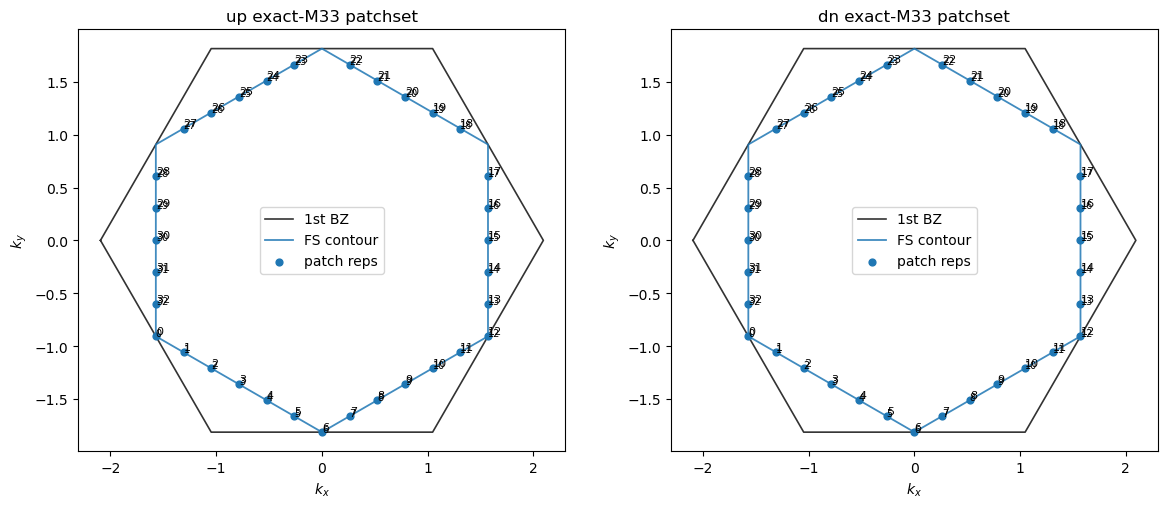

In [77]:

# ============================================================
# Required definitions BEFORE the manual exact-M patch cell
# ============================================================

# Example model params:
MODEL_PARAMS = {"t": 1.0, "phi": np.pi/4}
# If you already defined MODEL_PARAMS elsewhere, keep your own value.

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# Spinful KagomeNagaosa has 6 orbitals total:
#   up sector = first 3
#   dn sector = last 3
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)

# IMPORTANT:
# choose the band index within EACH 3x3 spin block.
# If your previous notebook already had the correct value, use that.
# For many kagome runs the local band index is often 1, but change it if needed.
LOCAL_BAND_INDEX = 1
import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(dict(t=1.0, phi=0.0), spin=True, B=None)

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 6           # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True # True: remove replicated M anchors modulo G
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        # keep_strict_M_anchors=False,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        # keep_strict_M_anchors=False
    ),
}

NPATCH = patchsets["up"].Npatch
PATCHSETS = patchsets

# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}"
    )

if REMOVE_DUPLICATE_M_MODG:
    keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, POINTS_PER_EDGE)
    print("\n===== kept indices in full loop =====")
    print(keep_idx.tolist())

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"k_can={np.round(_canonicalize_k_mod_G(model, p.k_cart), 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )

# ------------------------------------------------------------
# neighbor distance sanity check (patch reps only)
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances (patch reps only) =====")
    print(np.round(d, 8))

# ------------------------------------------------------------
# optional overlap sanity check for gauge smoothness
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    U = np.array([p.eigvec for p in patchsets[spin].patches], dtype=complex)
    ovs = []
    for i in range(len(U)):
        j = (i + 1) % len(U)
        ovs.append(np.vdot(U[i], U[j]))
    ovs = np.asarray(ovs, dtype=complex)

    print(f"\n===== {spin} neighbor overlaps after gauge fixing =====")
    print("abs  =", np.round(np.abs(ovs), 8))
    print("arg  =", np.round(np.angle(ovs), 8))

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(
        patchsets[spin],
        ax=ax,
        show_contour=True,   # contour remains the original full loop
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

# Model

CASE = V_only  | U = 0  V = 10.0
T_START, T_STOP, NFREQ, NSTEPS = 10.0 0.05 50 300
NPATCH = 33
diagnosis_Qs:
  Q0 = (0.000000, 0.000000)
  Q1 = (-1.570796, -0.906900)
  Q2 = (0.000000, -1.813799)
  Q3 = (-1.570796, 0.906900)

solver built.
temperature path length = 300
initial channel norm    = 20.000000000000007

=== bare (initial) sign-aware kernel metrics ===


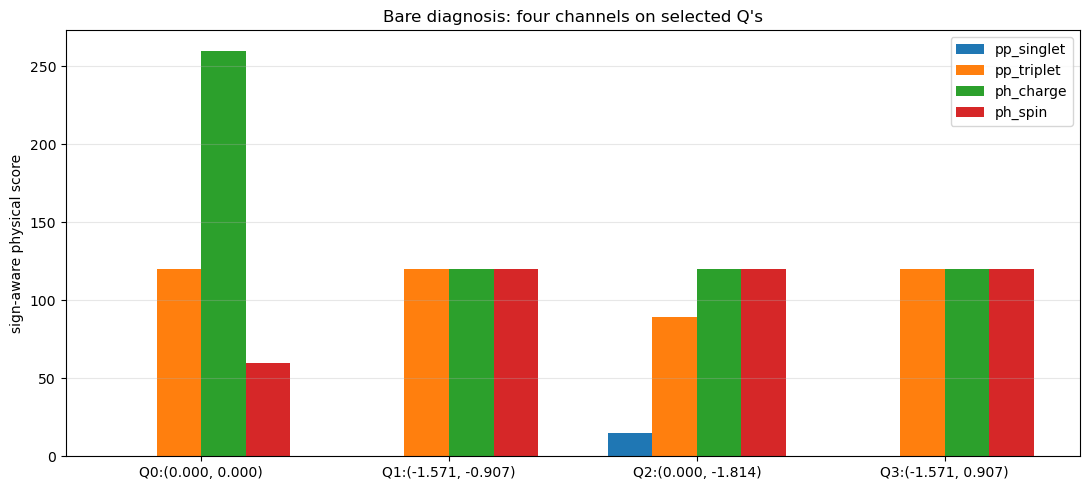


=== bare leader ===
channel : ph_charge
Q       : (0.000000, 0.000000)
score   : 2.600000000000e+02
chosen  : negative -2.600000000000e+02


In [79]:
# ------------------------------------------------------------
# choose interaction case
# ------------------------------------------------------------
CASE = "V_only"   # "V_only" or "U_only" or custom below

if CASE == "V_only":
    U_TEST, V_TEST = 0, 10.0
elif CASE == "U_only":
    U_TEST, V_TEST = 10.0, 0.0
else:
    raise ValueError("CASE must be 'V_only' or 'U_only'")

# ------------------------------------------------------------
# flow params
# ------------------------------------------------------------
T_START = 10.0
T_STOP  = 0.05
NFREQ   = 50
NSTEPS  = 300

M6 = exact_M6_points_1bz(model)

# Selected transfer momenta used in diagnosis
diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("NPATCH =", PATCHSETS["up"].Npatch)
print("diagnosis_Qs:")
for i, q in enumerate(diagnosis_Qs):
    print(f"  Q{i} = {fmt_q(q, nd=6)}")

bare_int = BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,
    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,

    # keep the adaptive integrator lenient enough for exploration
    max_relative_update=5.0,
    min_substep_fraction=1.0 / 512.0,

    # do not let raw vertex norm stop the flow too early
    channel_divergence_threshold=2e2,

    # sign-aware diagnosis monitored at selected Q's
    diagnosis_Qs=diagnosis_Qs,
    diagnosis_score_threshold=None,   # set a number later if you want sign-aware early stop
    diagnosis_landau_F=False,
)

print("\nsolver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm    =", solver.state.channel_norm())

# ============================================================
# Bare (initial) kernel metrics at Q=0 and Q=M's
# ============================================================
builder0 = build_sz0_builder_from_solver(solver, Landau_F=False)
df_bare, bare_store = evaluate_selected_Qs(builder0, diagnosis_Qs, landau_F=False)

print("\n=== bare (initial) sign-aware kernel metrics ===")
# display(df_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_signaware_bars(df_bare, title="Bare diagnosis: four channels on selected Q's")

best_bare = leading_row_from_df(df_bare)
print("\n=== bare leader ===")
print("channel :", best_bare["channel"])
print("Q       :", fmt_q(best_bare["Q"], nd=6))
print("score   :", f"{best_bare['physical_score']:.12e}")
print("chosen  :", best_bare["chosen_sign"], f"{best_bare['chosen_eval']:.12e}")

# Flow

In [37]:
print("start flow ...")
print("initial T =", solver.state.T)
print("n_steps   =", len(solver.temperature_path))
print("Npatch    =", solver.Npatch)
print()

SNAPSHOT_STEPS = [0, 160, 161, 162]

history, snapshots = manual_run_flow_live(
    solver,
    snapshot_steps=SNAPSHOT_STEPS,
)

print("saved snapshots:", sorted(snapshots.keys()))

print("\nrun finished.")
print("history length =", len(history))
print("instability_record =", solver.instability_record is not None)

if solver.instability_record is not None:
    rec = solver.instability_record
    print("\n=== instability record ===")
    print("step_index        :", rec.step_index)
    print("temperature       :", rec.temperature)
    print("instability       :", rec.instability)
    print("instability_reason:", rec.instability_reason)
    print("termination_reason:", rec.termination_reason)
    print("diagnosis keys    :", list(rec.diagnosis_payload.keys()))
else:
    print("No instability_record found.")

history_df = history_to_dataframe(history)
display(history_df.tail(10))

start flow ...
initial T = 10.0
n_steps   = 300
Npatch    = 21

step=   0 | T=10.000000 | rhs_norm=0.000e+00 | leader=ph_spin @ Q0:(0.000, 0.000) score=2.100e+01 | pp_singlet=4.832e-15, pp_triplet=1.600e+01, ph_charge=2.000e+01, ph_spin=2.100e+01
step=   1 | T=9.966722 | rhs_norm=1.177e+00 | leader=ph_spin @ Q0:(0.000, 0.000) score=2.094e+01 | pp_singlet=1.024e-01, pp_triplet=1.594e+01, ph_charge=1.998e+01, ph_spin=2.094e+01
step=   2 | T=9.933445 | rhs_norm=1.164e+00 | leader=ph_spin @ Q0:(0.000, 0.000) score=2.089e+01 | pp_singlet=2.039e-01, pp_triplet=1.588e+01, ph_charge=1.996e+01, ph_spin=2.089e+01
step=   3 | T=9.900167 | rhs_norm=1.151e+00 | leader=ph_spin @ Q0:(0.000, 0.000) score=2.083e+01 | pp_singlet=3.047e-01, pp_triplet=1.582e+01, ph_charge=1.994e+01, ph_spin=2.083e+01
step=   4 | T=9.866890 | rhs_norm=1.138e+00 | leader=ph_spin @ Q0:(0.000, 0.000) score=2.077e+01 | pp_singlet=4.047e-01, pp_triplet=1.577e+01, ph_charge=1.992e+01, ph_spin=2.077e+01
step=   5 | T=9.833612 | 

,step_index,T,dT,channel_norm,rhs_norm,accepted_substeps,max_rel_update,instability,instability_reason,termination_reason,leading_channel,leading_Q_index,leading_Qx,leading_Qy,leading_score
154,154,4.875251,-0.033278,12.927250,35.017949,1,0.098891,False,None,None,ph_spin,0,0.0,0.0,21.782593
155,155,4.841973,-0.033278,14.387785,44.690910,1,0.115044,False,None,None,ph_spin,0,0.0,0.0,22.957266
156,156,4.808696,-0.033278,16.311917,58.803032,1,0.136006,False,None,None,ph_spin,0,0.0,0.0,24.527943
157,157,4.775418,-0.033278,18.949681,80.404307,1,0.164031,False,None,None,ph_spin,0,0.0,0.0,26.710530
158,158,4.742140,-0.033278,22.746381,115.543976,1,0.202907,False,None,None,ph_spin,0,0.0,0.0,29.899200
159,159,4.708863,-0.033278,28.586349,177.425146,1,0.259570,False,None,None,ph_spin,0,0.0,0.0,34.881595
160,160,4.675585,-0.033278,38.435015,298.700630,1,0.347720,False,None,None,ph_spin,0,0.0,0.0,43.431815
161,161,4.642308,-0.033278,57.426415,575.030323,1,0.497870,False,None,None,ph_spin,0,0.0,0.0,60.261913
162,162,4.609030,-0.033278,102.516135,1363.161156,1,0.789928,False,None,None,ph_charge,0,0.0,0.0,105.702597
163,163,4.575753,-0.033278,254.401203,4585.985120,1,1.488649,True,channel norm=2.544e+02 exceeded channel_diverg...,None,ph_charge,0,0.0,0.0,262.610351


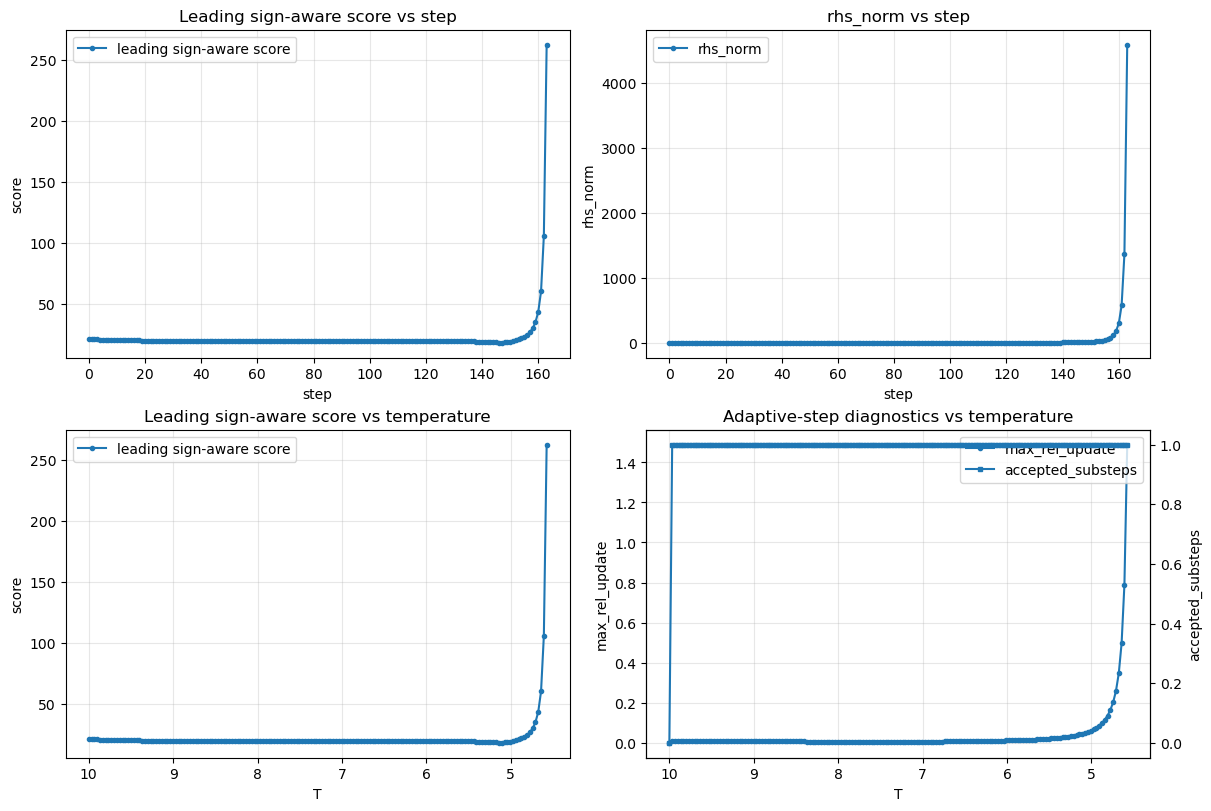

In [38]:
# ============================================================
# Flow history plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0,0].plot(history_df["step_index"], history_df["leading_score"], marker="o", ms=3, label="leading sign-aware score")
axes[0,0].set_title("Leading sign-aware score vs step")
axes[0,0].set_xlabel("step")
axes[0,0].set_ylabel("score")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

axes[0,1].plot(history_df["step_index"], history_df["rhs_norm"], marker="o", ms=3, label="rhs_norm")
axes[0,1].set_title("rhs_norm vs step")
axes[0,1].set_xlabel("step")
axes[0,1].set_ylabel("rhs_norm")
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

axes[1,0].plot(history_df["T"], history_df["leading_score"], marker="o", ms=3, label="leading sign-aware score")
axes[1,0].invert_xaxis()
axes[1,0].set_title("Leading sign-aware score vs temperature")
axes[1,0].set_xlabel("T")
axes[1,0].set_ylabel("score")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

ax = axes[1,1]
ax.plot(history_df["T"], history_df["max_rel_update"], marker="o", ms=3, label="max_rel_update")
ax.invert_xaxis()
ax.set_xlabel("T")
ax.set_ylabel("max_rel_update")
ax.grid(True, alpha=0.3)
ax2 = ax.twinx()
ax2.plot(history_df["T"], history_df["accepted_substeps"], marker="s", ms=3, label="accepted_substeps")
ax2.set_ylabel("accepted_substeps")
ax.set_title("Adaptive-step diagnostics vs temperature")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()

# Final diagnosis

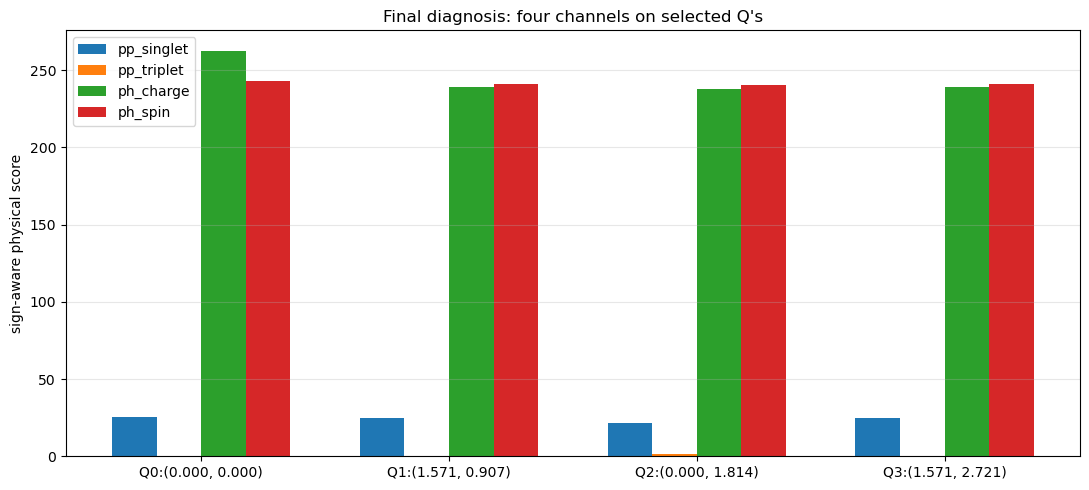


=== leader eigenstate summary ===
channel            : ph_charge
Q                  : (0.000000, 0.000000)
selected eigenvalue: -2.626103507451e+02
kernel dimension   : 21
|<u_const|v>|      : 9.714451465470e-17


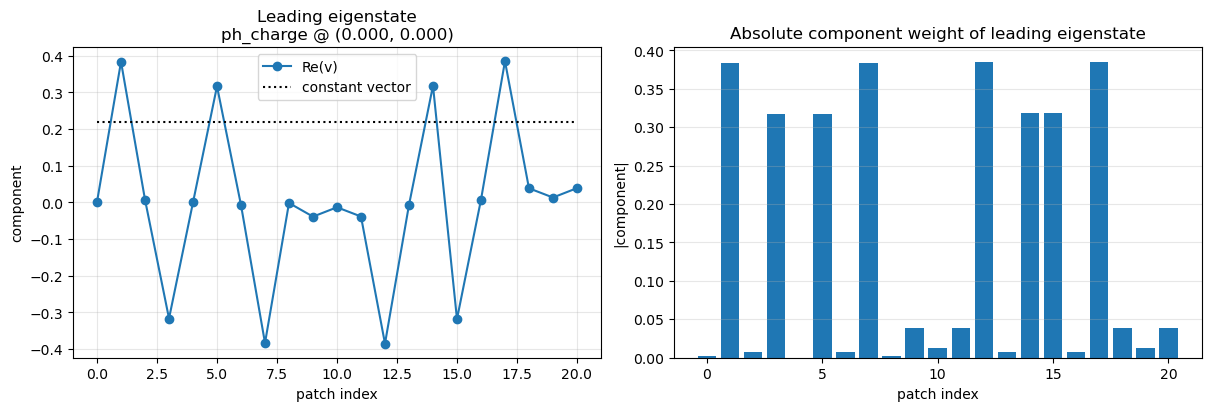

In [40]:
# ============================================================
# Final diagnosis on selected Q's
#   - bar chart
#   - maximal kernel eigenstate
# ============================================================
last_rec = solver.history[-1]
payload = last_rec.diagnosis_payload

if "sign_aware" not in payload:
    raise RuntimeError(
        "No sign_aware diagnosis found in solver.history[-1]. "
        "Please make sure diagnosis_Qs was passed into the solver."
    )

sa = payload["sign_aware"]
df_final = pd.DataFrame(sa["rows"])
# display(df_final.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_signaware_bars(df_final, title="Final diagnosis: four channels on selected Q's")

# print("\n=== final leader ===")
# print("channel :", sa["leading_channel"])
# print("Q       :", fmt_q(sa["leading_Q"], nd=6))
# print("score   :", f"{sa['leading_score']:.12e}")
# print("chosen  :", sa["leading_chosen_sign"], f"{sa['leading_chosen_eval']:.12e}")

# Rebuild final kernels from the current solver state
builder_final = build_sz0_builder_from_solver(solver, Landau_F=False)
kernel_dict = builder_final.build_kernel_dict(np.asarray(sa["leading_Q"], dtype=float), Landau_F=False)
lead_kernel = kernel_dict[sa["leading_channel"]]

lead_val, lead_vec = choose_signaware_eigenpair(sa["leading_channel"], lead_kernel.matrix)

# Fix the global phase for readability
imax = int(np.argmax(np.abs(lead_vec)))
phase = np.angle(lead_vec[imax]) if np.abs(lead_vec[imax]) > 1e-14 else 0.0
lead_vec = lead_vec * np.exp(-1j * phase)

print("\n=== leader eigenstate summary ===")
print("channel            :", sa["leading_channel"])
print("Q                  :", fmt_q(sa["leading_Q"], nd=6))
print("selected eigenvalue:", f"{lead_val:.12e}")
print("kernel dimension   :", len(lead_vec))

u_const = np.ones(len(lead_vec), dtype=complex) / np.sqrt(len(lead_vec))
const_overlap = abs(np.vdot(u_const, lead_vec))
print("|<u_const|v>|      :", f"{const_overlap:.12e}")

df_eig = pd.DataFrame({
    "patch": np.arange(len(lead_vec)),
    "vec_real": np.real(lead_vec),
    "vec_imag": np.imag(lead_vec),
    "vec_abs": np.abs(lead_vec),
    "const_real": np.real(u_const),
})
# display(df_eig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(np.arange(len(lead_vec)), np.real(lead_vec), "o-", label="Re(v)")
if np.max(np.abs(np.imag(lead_vec))) > 1e-10:
    axes[0].plot(np.arange(len(lead_vec)), np.imag(lead_vec), "s--", label="Im(v)")
axes[0].plot(np.arange(len(lead_vec)), np.real(u_const), "k:", label="constant vector")
axes[0].set_title(f"Leading eigenstate\n{sa['leading_channel']} @ {fmt_q(sa['leading_Q'])}")
axes[0].set_xlabel("patch index")
axes[0].set_ylabel("component")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(np.arange(len(lead_vec)), np.abs(lead_vec))
axes[1].set_title("Absolute component weight of leading eigenstate")
axes[1].set_xlabel("patch index")
axes[1].set_ylabel("|component|")
axes[1].grid(True, axis="y", alpha=0.3)

plt.show()

# Instability

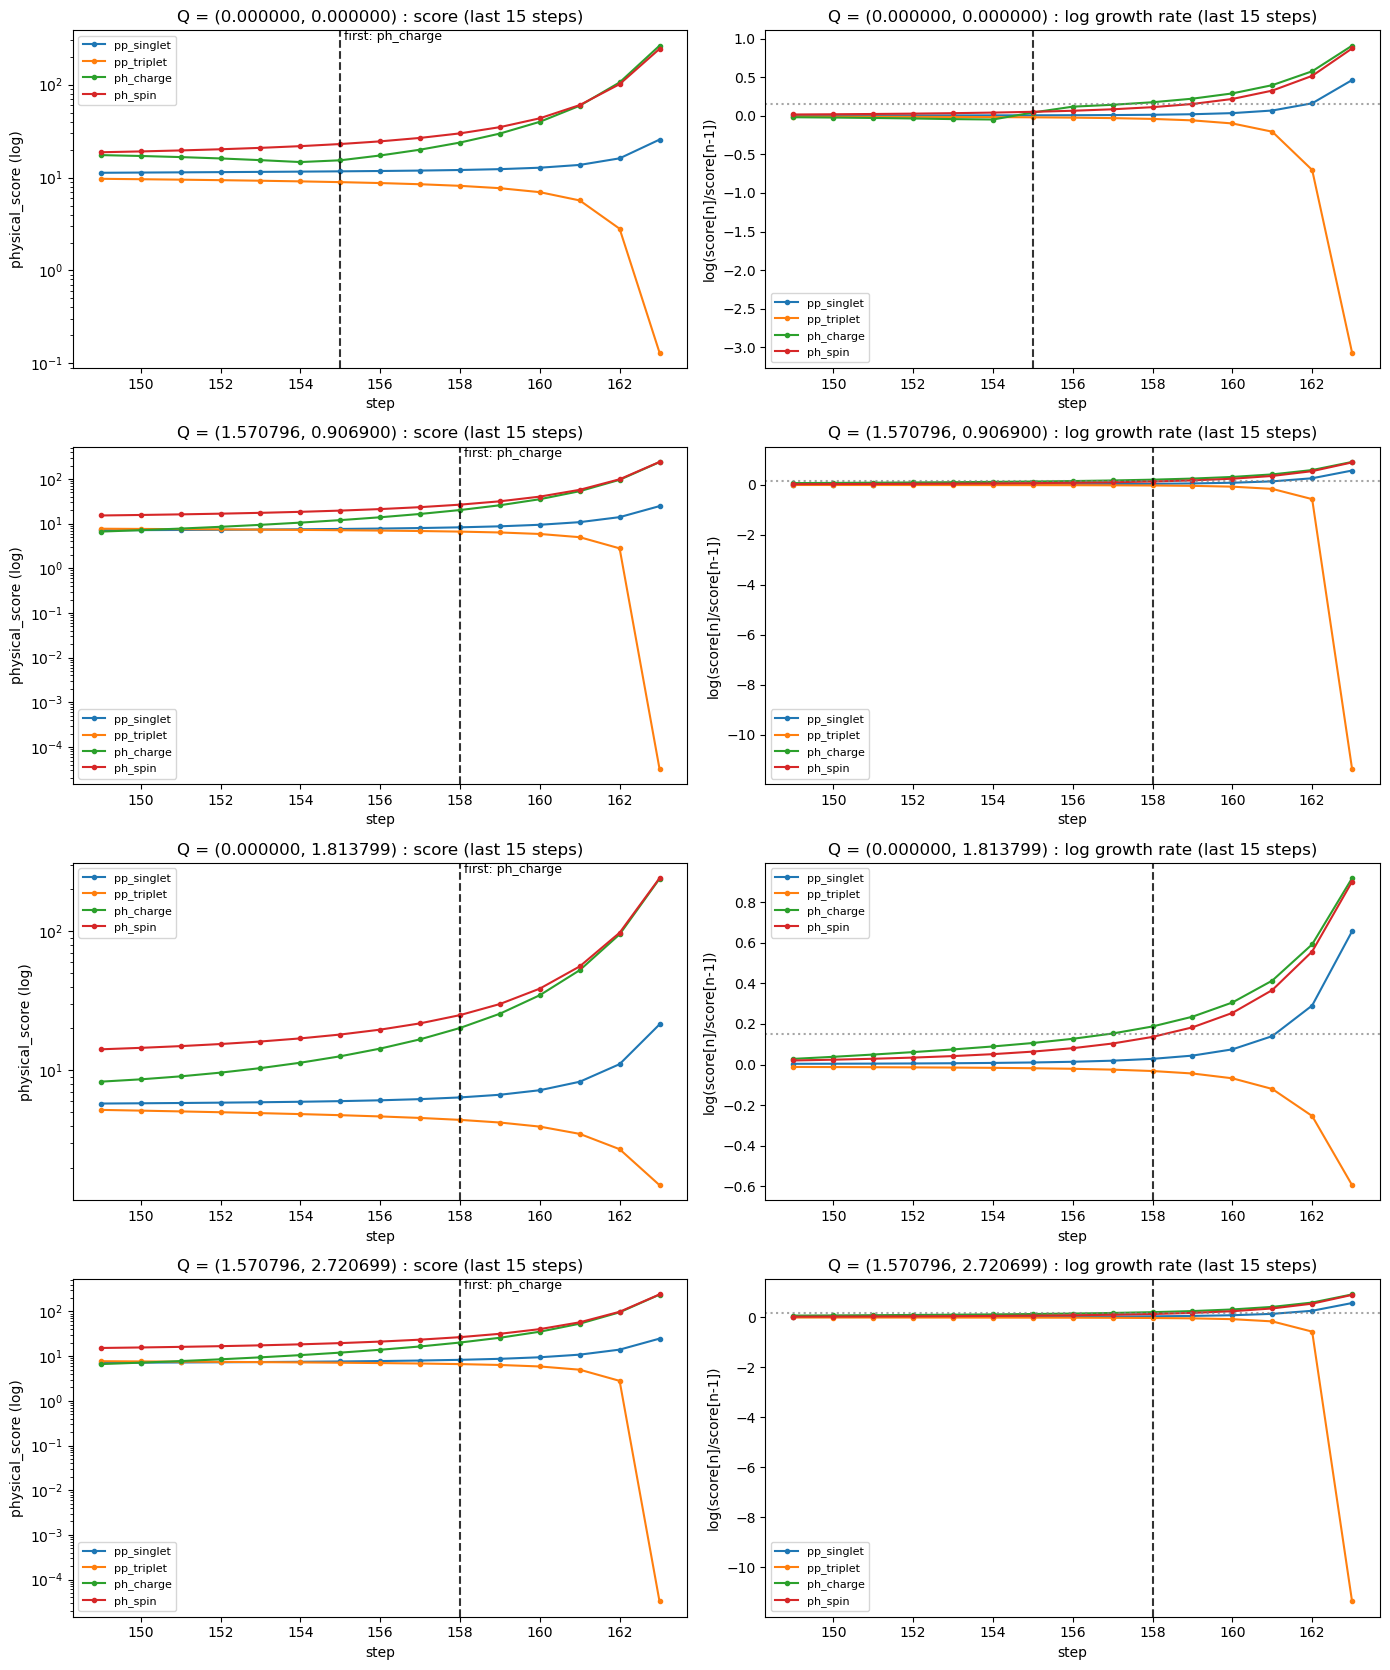

=== Earliest onset for each Q ===


,Q_key,channel,onset_step,T_at_onset,score_at_onset
0,"(0.000000, 0.000000)",ph_charge,155.0,4.841973,15.340794
1,"(0.000000, 1.813799)",ph_charge,158.0,4.742140,20.175221
2,"(1.570796, 0.906900)",ph_charge,158.0,4.742140,20.189366
3,"(1.570796, 2.720699)",ph_charge,158.0,4.742140,20.189366



=== Global earliest onset ===
Q = (0.000000, 0.000000), channel = ph_charge, onset_step = 155, T = 4.841973, score = 15.3408


In [50]:
# ============================================================
# 参数区：你以后主要改这里
# ============================================================

# 1. 目标 Q：优先用 FLOW_KWARGS['diagnosis_Qs']，否则用 solver.diagnosis_Qs
if "FLOW_KWARGS" in globals() and "diagnosis_Qs" in FLOW_KWARGS:
    TARGET_QS = [np.asarray(q, dtype=float) for q in FLOW_KWARGS["diagnosis_Qs"]]
elif "solver" in globals() and getattr(solver, "diagnosis_Qs", None) is not None:
    TARGET_QS = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]
else:
    raise ValueError("没有找到 diagnosis_Qs。请确认 FLOW_KWARGS['diagnosis_Qs'] 或 solver.diagnosis_Qs 存在。")

TARGET_Q_KEYS = [q_to_key(q) for q in TARGET_QS]

# 2. onset 判据参数
MIN_STEP   = 5
RATIO_TH   = 1.2
LOGRATE_TH = 0.15
ACCEL_TH   = 0.05
SUSTAIN    = 2
ABS_SCORE_MIN = 1.0
REL_SCORE_MIN = 1e-2
# 3. 可视化参数
TAIL_STEPS = 15

# ============================================================
# 运行区
# ============================================================

score_df = build_score_df_from_history(
    history=history,
    target_q_keys=TARGET_Q_KEYS,
    channels=CHANNELS,
)

growth_data = build_growth_data(
    score_df=score_df,
    channels=CHANNELS,
)

onset_df = build_onset_df(
    growth_data=growth_data,
    target_q_keys=TARGET_Q_KEYS,
    channels=CHANNELS,
    min_step=MIN_STEP,
    ratio_th=RATIO_TH,
    lograte_th=LOGRATE_TH,
    accel_th=ACCEL_TH,
    sustain=SUSTAIN,
    # abs_score_min = ABS_SCORE_MIN,
    # rel_score_min = REL_SCORE_MIN
)

per_q_first, global_first = summarize_onsets(onset_df)

plot_growth_tail(
    growth_data=growth_data,
    per_q_first=per_q_first,
    target_q_keys=TARGET_Q_KEYS,
    channels=CHANNELS,
    tail_steps=TAIL_STEPS,
    lograte_th=LOGRATE_TH,
)

print("=== Earliest onset for each Q ===")
display(per_q_first[["Q_key", "channel", "onset_step", "T_at_onset", "score_at_onset"]])

if global_first is not None:
    print("\n=== Global earliest onset ===")
    print(
        f"Q = {global_first['Q_key']}, "
        f"channel = {global_first['channel']}, "
        f"onset_step = {int(global_first['onset_step'])}, "
        f"T = {global_first['T_at_onset']:.6f}, "
        f"score = {global_first['score_at_onset']:.6g}"
    )
else:
    print("\n没有检测到满足当前判据的 onset；可以适当降低阈值。")

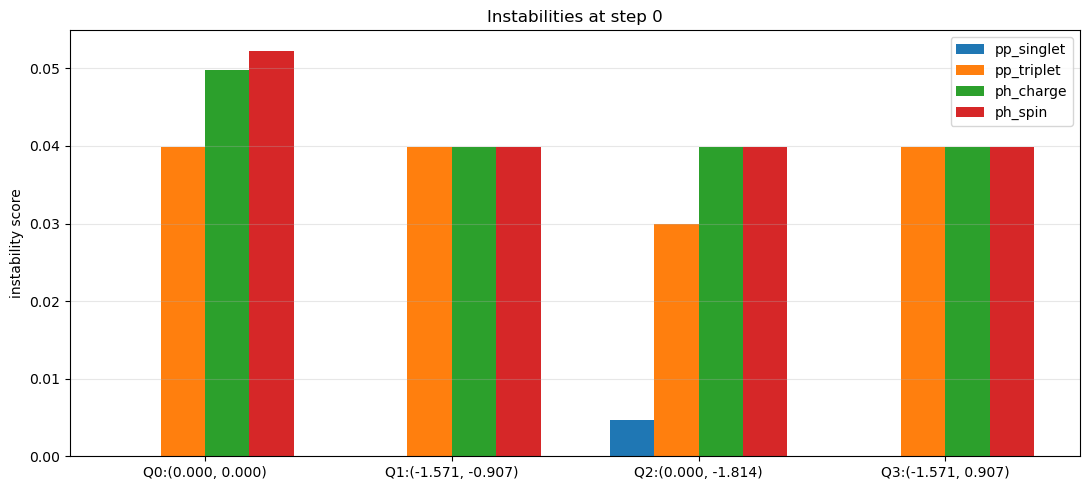

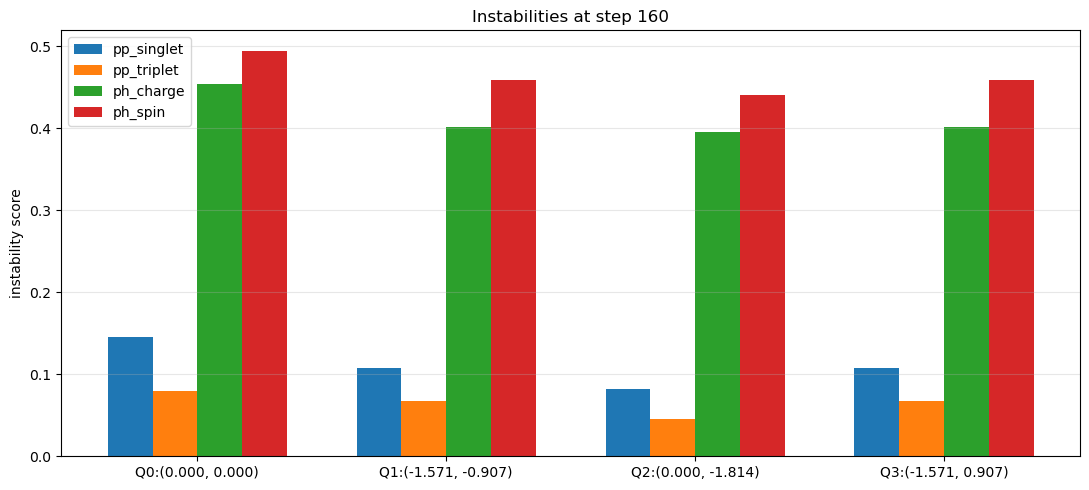

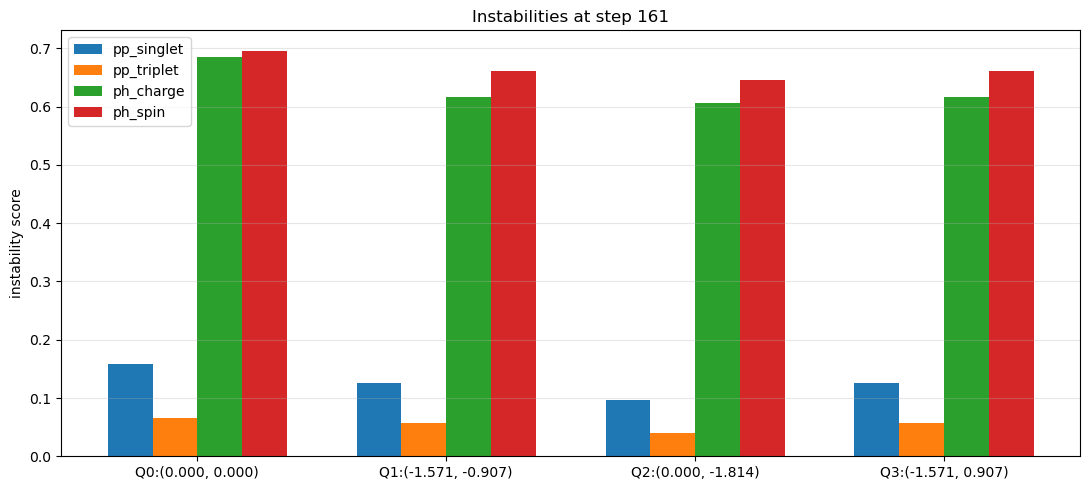

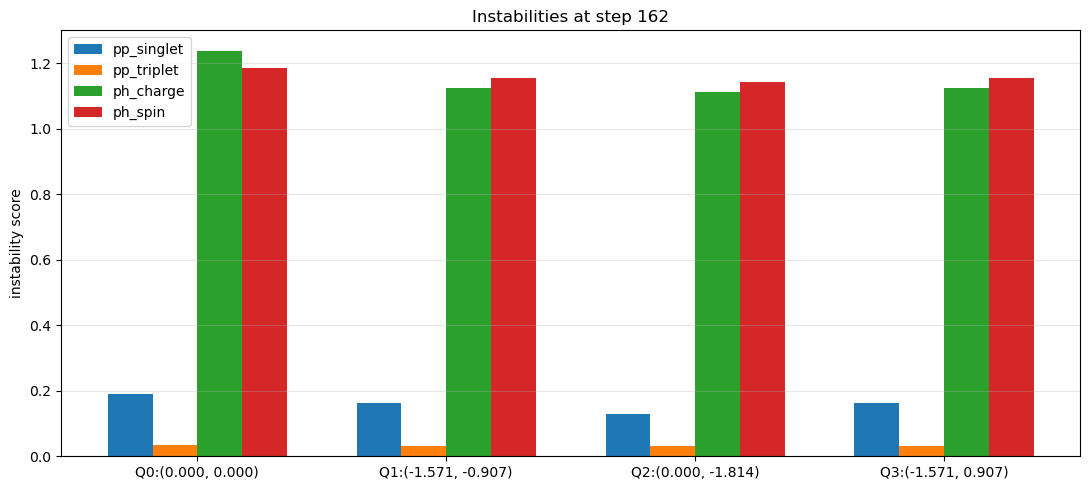

In [51]:
results_1, df_inst_1 = diagnose_snapshot_instabilities(
    snapshots[SNAPSHOT_STEPS[0]], solver, diagnosis_Qs
)
results_2, df_inst_2 = diagnose_snapshot_instabilities(
    snapshots[SNAPSHOT_STEPS[1]], solver, diagnosis_Qs
)
results_3, df_inst_3 = diagnose_snapshot_instabilities(
    snapshots[SNAPSHOT_STEPS[2]], solver, diagnosis_Qs
)
results_4, df_inst_4 = diagnose_snapshot_instabilities(
    snapshots[SNAPSHOT_STEPS[3]], solver, diagnosis_Qs
)
plot_instability_bars(df_inst_1, title=f"Instabilities at step {SNAPSHOT_STEPS[0]}")
plot_instability_bars(df_inst_2, title=f"Instabilities at step {SNAPSHOT_STEPS[1]}")
plot_instability_bars(df_inst_3, title=f"Instabilities at step {SNAPSHOT_STEPS[2]}")
plot_instability_bars(df_inst_4, title=f"Instabilities at step {SNAPSHOT_STEPS[3]}")

# Debug

Scanning row 1/21 : V=0.000
Scanning row 2/21 : V=1.000
Scanning row 3/21 : V=2.000
Scanning row 4/21 : V=3.000
Scanning row 5/21 : V=4.000
Scanning row 6/21 : V=5.000
Scanning row 7/21 : V=6.000
Scanning row 8/21 : V=7.000
Scanning row 9/21 : V=8.000
Scanning row 10/21 : V=9.000
Scanning row 11/21 : V=10.000
Scanning row 12/21 : V=11.000
Scanning row 13/21 : V=12.000
Scanning row 14/21 : V=13.000
Scanning row 15/21 : V=14.000
Scanning row 16/21 : V=15.000
Scanning row 17/21 : V=16.000
Scanning row 18/21 : V=17.000
Scanning row 19/21 : V=18.000
Scanning row 20/21 : V=19.000
Scanning row 21/21 : V=20.000


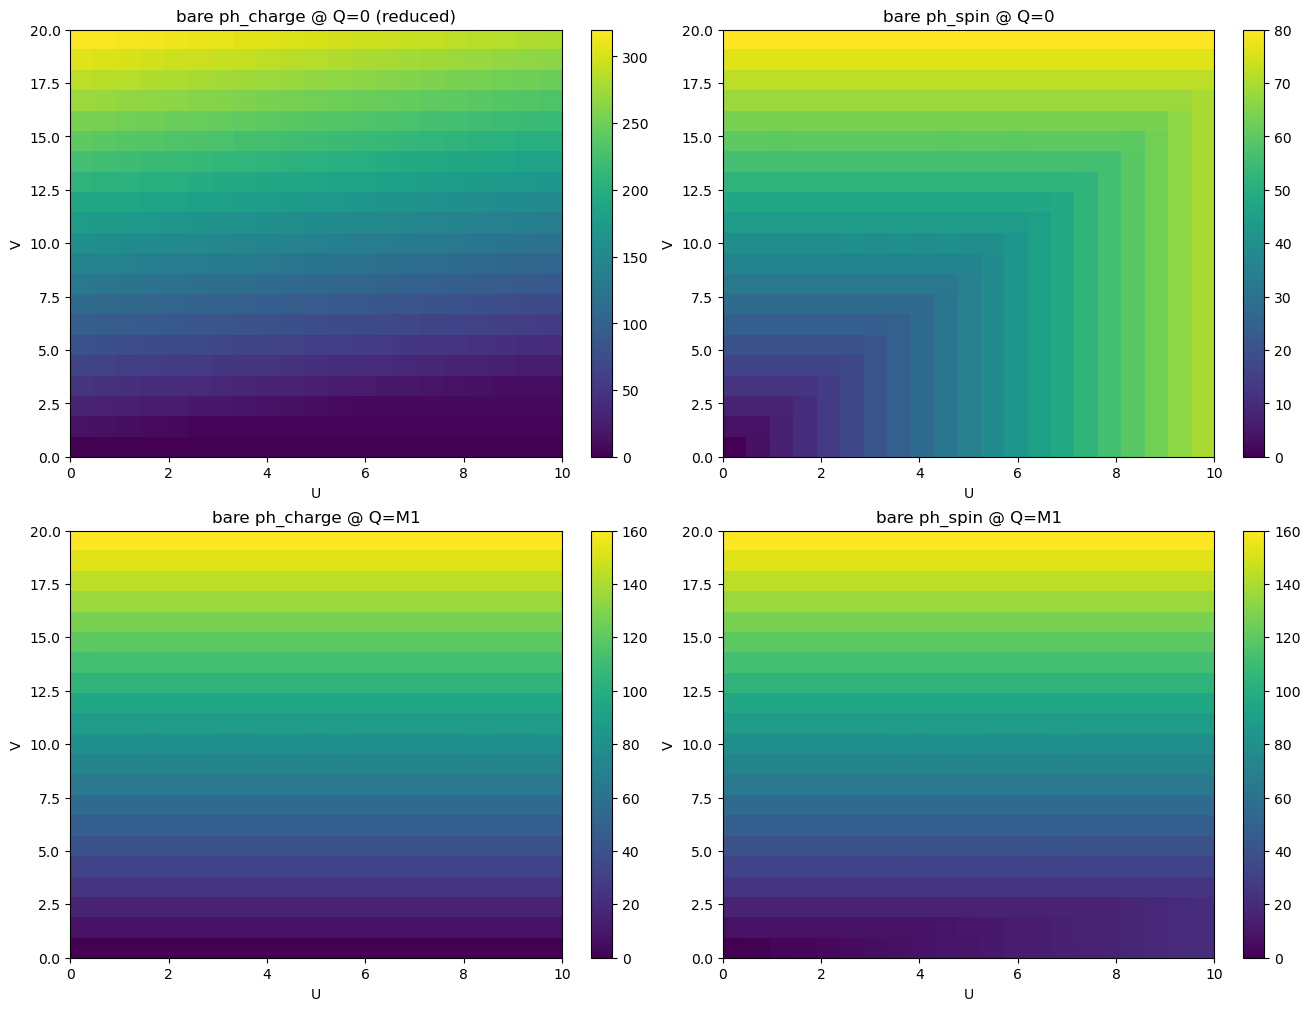


=== points where M1 beats Q0 ===
ph_charge: [[ 1  5]
 [ 1  6]
 [ 1  7]
 [ 1  8]
 [ 1  9]
 [ 1 10]
 [ 1 11]
 [ 1 12]
 [ 1 13]
 [ 1 14]
 [ 1 15]
 [ 1 16]
 [ 1 17]
 [ 1 18]
 [ 1 19]
 [ 1 20]
 [ 2  9]
 [ 2 10]
 [ 2 11]
 [ 2 12]
 [ 2 13]
 [ 2 14]
 [ 2 15]
 [ 2 16]
 [ 2 17]
 [ 2 18]
 [ 2 19]
 [ 2 20]
 [ 3 13]
 [ 3 14]
 [ 3 15]
 [ 3 16]
 [ 3 17]
 [ 3 18]
 [ 3 19]
 [ 3 20]
 [ 4 17]
 [ 4 18]
 [ 4 19]
 [ 4 20]]
ph_spin  : [[ 1  0]
 [ 1  1]
 [ 1  2]
 [ 2  0]
 [ 2  1]
 [ 2  2]
 [ 2  3]
 [ 2  4]
 [ 3  0]
 [ 3  1]
 [ 3  2]
 [ 3  3]
 [ 3  4]
 [ 3  5]
 [ 3  6]
 [ 4  0]
 [ 4  1]
 [ 4  2]
 [ 4  3]
 [ 4  4]
 [ 4  5]
 [ 4  6]
 [ 4  7]
 [ 4  8]
 [ 4  9]
 [ 5  0]
 [ 5  1]
 [ 5  2]
 [ 5  3]
 [ 5  4]
 [ 5  5]
 [ 5  6]
 [ 5  7]
 [ 5  8]
 [ 5  9]
 [ 5 10]
 [ 5 11]
 [ 6  0]
 [ 6  1]
 [ 6  2]
 [ 6  3]
 [ 6  4]
 [ 6  5]
 [ 6  6]
 [ 6  7]
 [ 6  8]
 [ 6  9]
 [ 6 10]
 [ 6 11]
 [ 6 12]
 [ 6 13]
 [ 7  0]
 [ 7  1]
 [ 7  2]
 [ 7  3]
 [ 7  4]
 [ 7  5]
 [ 7  6]
 [ 7  7]
 [ 7  8]
 [ 7  9]
 [ 7 10]
 [ 7 11]
 [ 7 12]
 [ 7 13

In [9]:
# ==== scan bare channel scores on a (U,V) grid ====
import numpy as np
import matplotlib.pyplot as plt

from interaction import BareExtendedHubbard
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from channels import SZ0ChannelBuilder

# =========================================================
# USER INPUTS
# =========================================================
# 你的非相互作用 kagome model 对象
# 例如: model = Kagome_Model(...)
# 要求它至少有 delta1, delta2, delta3，供 BareExtendedHubbard.from_kagome_model 使用
# 并且你的 patchsets 已经构造好
#
# model = ...
# patchsets = ...

# U,V 扫描范围
U_vals = np.linspace(0.0, 10.0, 21)   # 例如 0,0.5,...,10
V_vals = np.linspace(0.0, 20.0, 21)

# 选择一个 M 点
Q0 = np.array([0.0, 0.0])
QM1 = np.array([-np.pi/2, -np.sqrt(3)*np.pi/6])   # 如果你有更精确的 M1，就替换这里

# 是否对 Q=0 的 ph_charge 做你正式 diagnosis 里的 uniform-mode projection
# True  = 用正式 reduced 版本
# False = 看 raw ph_charge
USE_REDUCED_Q0_CHARGE = True

# 为了构造 builder，需要一个 solver 提供 transfer grids / closure map
# 这里只是 bare diagnosis，所以 T_start / n_steps / nfreq 随便给，只要能初始化 solver 即可
FLOW_INIT_KW = dict(
    T_start=10.0,
    T_stop=9.0,
    n_steps=2,
    nfreq=16,
    temperature_grid="linear",
    channel_divergence_threshold=1e12,
    diagnose_every=1,
    diagnosis_landau_F=not USE_REDUCED_Q0_CHARGE,  # 和 channels.py 的 Landau_F 语义保持一致
)

# =========================================================
# HELPERS
# =========================================================
def ph_score_from_kernel_matrix(M: np.ndarray) -> float:
    H = 0.5 * (M + M.conjugate().T)
    evals = np.linalg.eigvalsh(H)
    return max(-float(evals[0]), 0.0)

def build_bare_builder(model, patchsets, U, V):
    bare_int = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_vertex = BareSZ0VertexFromInteraction(bare_int, patchsets)

    # 用 bare vertex 初始化一个最小 solver，只为拿 transfer grids / closure map
    solver = FRGFlowSolverSZ0(
        patchsets=patchsets,
        bare_vertex=bare_vertex,
        **FLOW_INIT_KW,
    )

    builder = SZ0ChannelBuilder.from_solver(
        solver.state.bare_vertex,
        solver,
        Landau_F=not USE_REDUCED_Q0_CHARGE,  # channels.py: Landau_F=False 时，Q=0 ph_charge 会被 reduced
    )
    return builder

def bare_scores_for_one_point(model, patchsets, U, V, Q0, QM1):
    builder = build_bare_builder(model, patchsets, U, V)

    # Q=0
    K_c_q0 = builder.ph_charge(Q0, Landau_F=not USE_REDUCED_Q0_CHARGE).matrix
    K_s_q0 = builder.ph_spin(Q0).matrix

    # Q=M1
    K_c_qm = builder.ph_charge(QM1, Landau_F=True).matrix  # finite Q 不需要 reduced
    K_s_qm = builder.ph_spin(QM1).matrix

    return (
        ph_score_from_kernel_matrix(K_c_q0),
        ph_score_from_kernel_matrix(K_s_q0),
        ph_score_from_kernel_matrix(K_c_qm),
        ph_score_from_kernel_matrix(K_s_qm),
    )

# =========================================================
# MAIN SCAN
# =========================================================
score_phc_q0 = np.zeros((len(V_vals), len(U_vals)))
score_phs_q0 = np.zeros((len(V_vals), len(U_vals)))
score_phc_qm = np.zeros((len(V_vals), len(U_vals)))
score_phs_qm = np.zeros((len(V_vals), len(U_vals)))

for iV, V in enumerate(V_vals):
    print(f"Scanning row {iV+1}/{len(V_vals)} : V={V:.3f}")
    for iU, U in enumerate(U_vals):
        s_c0, s_s0, s_cm, s_sm = bare_scores_for_one_point(
            model, patchsets, U, V, Q0, QM1
        )
        score_phc_q0[iV, iU] = s_c0
        score_phs_q0[iV, iU] = s_s0
        score_phc_qm[iV, iU] = s_cm
        score_phs_qm[iV, iU] = s_sm

# =========================================================
# PLOT
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

plots = [
    (score_phc_q0, r"bare ph_charge @ Q=0" + (" (reduced)" if USE_REDUCED_Q0_CHARGE else " (raw)")),
    (score_phs_q0, r"bare ph_spin @ Q=0"),
    (score_phc_qm, r"bare ph_charge @ Q=M1"),
    (score_phs_qm, r"bare ph_spin @ Q=M1"),
]

for ax, (Z, title) in zip(axes.ravel(), plots):
    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[U_vals[0], U_vals[-1], V_vals[0], V_vals[-1]],
    )
    ax.set_title(title)
    ax.set_xlabel("U")
    ax.set_ylabel("V")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

# =========================================================
# OPTIONAL: where does M1 beat Q0 ?
# =========================================================
mask_phc = score_phc_qm > score_phc_q0
mask_phs = score_phs_qm > score_phs_q0

print("\n=== points where M1 beats Q0 ===")
print("ph_charge:", np.argwhere(mask_phc))
print("ph_spin  :", np.argwhere(mask_phs))

# 如果你想把这些点转成 (U,V) 列表：
uv_list_phc = [(U_vals[j], V_vals[i]) for i, j in np.argwhere(mask_phc)]
uv_list_phs = [(U_vals[j], V_vals[i]) for i, j in np.argwhere(mask_phs)]

print("\n(U,V) where bare ph_charge(M1) > bare ph_charge(Q0):")
print(uv_list_phc)

print("\n(U,V) where bare ph_spin(M1) > bare ph_spin(Q0):")
print(uv_list_phs)


=== bare ph_charge eigenstate diagnostics ===
Q = [0. 0.]
kernel name = ph_charge_q0_reduced
matrix shape = (21, 21)
hermitian residual of raw kernel = 3.019806626980426e-14
most negative eigenvalue = -140.0
constant-mode overlap = 3.607422824576691e-17

most negative eigenvalues:
  -1.400000000000e+02
  -1.400000000000e+02
  -4.000000000000e+01
  -4.000000000000e+01
  -4.000000000000e+01
  -3.648215737759e-14
  -2.882017885309e-14
  -1.545067941721e-14

most positive eigenvalues:
  7.553078467795e-16
  1.079795058788e-15
  7.191759888267e-15
  9.528677531648e-15
  1.127454958546e-14
  1.515672507561e-14
  2.306041799896e-14
  3.019607748531e-14


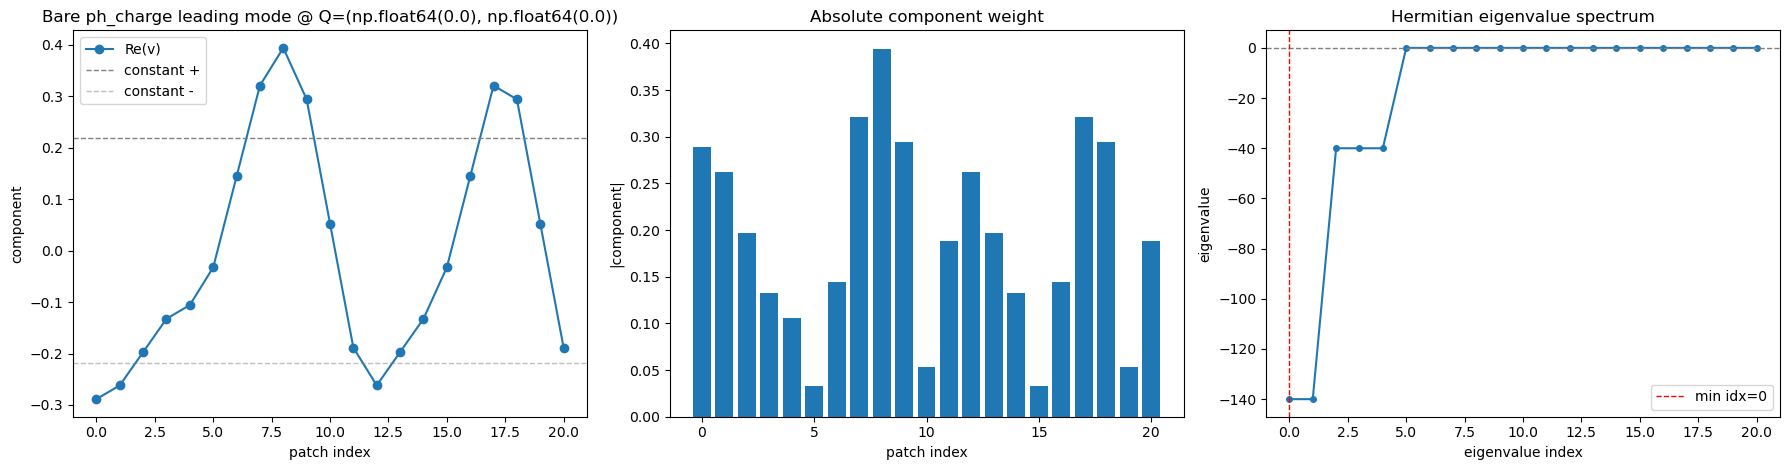

In [4]:
# ==== bare ph_charge eigenstate at chosen Q ====
import numpy as np
import matplotlib.pyplot as plt

from channels import SZ0ChannelBuilder

# -----------------------------
# user options
# -----------------------------
Q_to_plot = np.array([0.0, 0.0])   # 先看 Q=0
USE_REDUCED_Q0_CHARGE = True       # True: 投影掉 Q=0 uniform charge mode
N_SHOW_EVALS = 8                   # 显示前几个最负/最正本征值
PHASE_FIX = True                   # 给本征态统一相位，方便看实部

# -----------------------------
# get bare vertex + builder
# -----------------------------
# 你当前 solver 如果名字不是 solver，请改成你自己的对象名
bare_vertex_obj = solver.state.bare_vertex   # 如果这里报错，可改成你 notebook 里的 bare_vertex 变量
builder = SZ0ChannelBuilder.from_solver(
    bare_vertex_obj,
    solver,
    Landau_F=not USE_REDUCED_Q0_CHARGE   # 注意：Landau_F=False 才会对 Q=0 charge 做投影
)

# -----------------------------
# build bare ph_charge kernel
# -----------------------------
ker = builder.ph_charge(Q_to_plot, Landau_F=not USE_REDUCED_Q0_CHARGE)
K = np.asarray(ker.matrix, dtype=complex)
H = 0.5 * (K + K.conjugate().T)

# -----------------------------
# diagonalize Hermitian part
# ph channel: physically relevant mode = most negative eigenvalue
# -----------------------------
evals, evecs = np.linalg.eigh(H)
idx_min = np.argmin(evals)
lam_min = float(evals[idx_min])
v = np.asarray(evecs[:, idx_min], dtype=complex)

# phase-fix so the largest component is real-positive
if PHASE_FIX:
    j = int(np.argmax(np.abs(v)))
    if np.abs(v[j]) > 0:
        v = v * np.exp(-1j * np.angle(v[j]))

# normalize
v = v / np.linalg.norm(v)

# constant vector overlap
N = len(v)
u_const = np.ones(N, dtype=complex) / np.sqrt(N)
const_overlap = abs(np.vdot(u_const, v))

# some diagnostics
herm_resid = np.max(np.abs(K - K.conjugate().T))
print("=== bare ph_charge eigenstate diagnostics ===")
print("Q =", np.asarray(Q_to_plot, dtype=float))
print("kernel name =", ker.name)
print("matrix shape =", H.shape)
print("hermitian residual of raw kernel =", herm_resid)
print("most negative eigenvalue =", lam_min)
print("constant-mode overlap =", const_overlap)

print("\nmost negative eigenvalues:")
for x in evals[:N_SHOW_EVALS]:
    print(f"  {x:.12e}")

print("\nmost positive eigenvalues:")
for x in evals[-N_SHOW_EVALS:]:
    print(f"  {x:.12e}")

# -----------------------------
# plots
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# (1) real / imag components
axes[0].plot(np.arange(N), np.real(v), marker='o', label='Re(v)')
if np.max(np.abs(np.imag(v))) > 1e-10:
    axes[0].plot(np.arange(N), np.imag(v), marker='s', label='Im(v)')
axes[0].axhline(1/np.sqrt(N), color='gray', ls='--', lw=1, label='constant +')
axes[0].axhline(-1/np.sqrt(N), color='gray', ls='--', lw=1, alpha=0.5, label='constant -')
axes[0].set_title(f"Bare ph_charge leading mode @ Q={tuple(np.round(Q_to_plot, 6))}")
axes[0].set_xlabel("patch index")
axes[0].set_ylabel("component")
axes[0].legend()

# (2) absolute weights
axes[1].bar(np.arange(N), np.abs(v))
axes[1].set_title("Absolute component weight")
axes[1].set_xlabel("patch index")
axes[1].set_ylabel("|component|")

# (3) eigenvalue spectrum
axes[2].plot(np.arange(len(evals)), evals, marker='o', ms=4)
axes[2].axhline(0.0, color='gray', ls='--', lw=1)
axes[2].axvline(idx_min, color='r', ls='--', lw=1, label=f"min idx={idx_min}")
axes[2].set_title("Hermitian eigenvalue spectrum")
axes[2].set_xlabel("eigenvalue index")
axes[2].set_ylabel("eigenvalue")
axes[2].legend()

plt.tight_layout()
plt.show()